# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [23]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [24]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


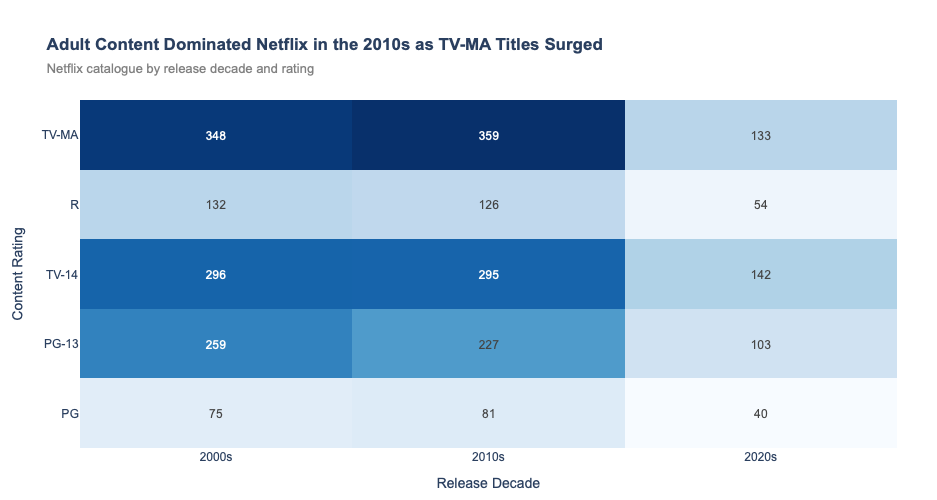

In [25]:
# Task 1
# HEATMAP — Netflix ratings across decades

import pandas as pd
import plotly.express as px

# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Filter to selected ratings
target_ratings = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']

df_filtered = df[df['rating'].isin(target_ratings)].copy()

# Create heatmap data
heatmap_data = (
    df_filtered.groupby(['rating', 'decade'])
    .size()
    .unstack(fill_value=0)
)

# Reorder rows
heatmap_data = heatmap_data.reindex(
    ['TV-MA', 'R', 'TV-14', 'PG-13', 'PG']
)

# Build heatmap
fig1 = px.imshow(
    heatmap_data,
    labels=dict(
        x="Release Decade",
        y="Content Rating",
        color="Titles"
    ),
    x=heatmap_data.columns,
    y=heatmap_data.index,
    color_continuous_scale='Blues',
    text_auto=True,
    aspect='auto',
    title='<b>Adult Content Dominated Netflix in the 2010s as TV-MA Titles Surged</b><br><span style="font-size:13px;color:gray;">Netflix catalogue by release decade and rating</span>'
)

# Layout improvements
fig1.update_layout(
    font=dict(family='Arial'),
    coloraxis_showscale=False,
    width=900,
    height=500,
    margin=dict(t=100, b=50, l=80, r=40)
)

# Text styling
fig1.update_traces(
    textfont=dict(size=12)
)

fig1.show()

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


   added_year  Count
0        2015     71
1        2016     93
2        2017     77
3        2018     79
4        2019     93
5        2020     81
6        2021     83
7        2022     82


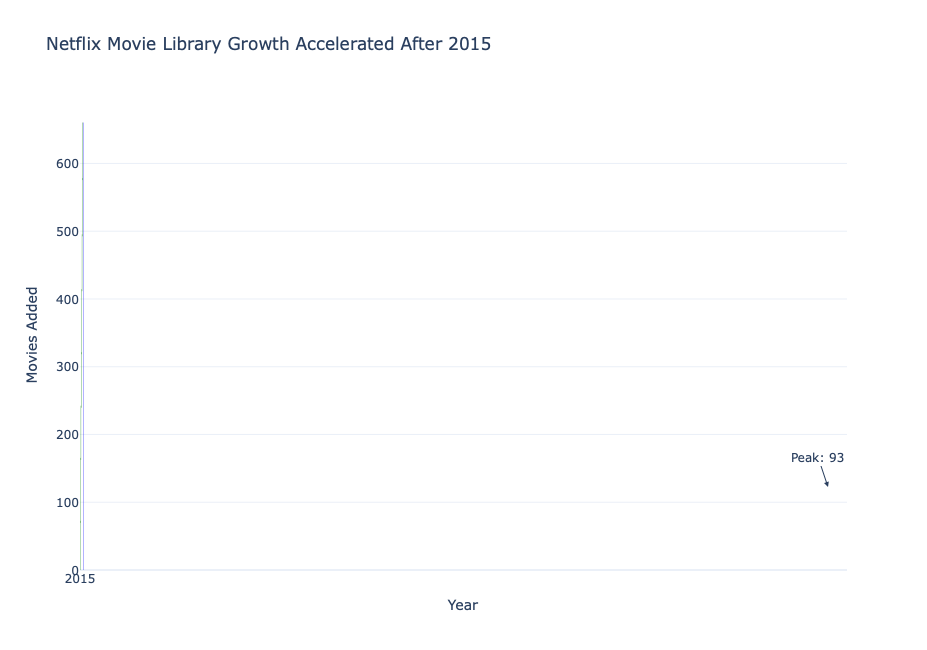

In [26]:
# Task 2 — Waterfall: Netflix movie additions by year

import pandas as pd
import plotly.graph_objects as go

# Clean added_year column
df['added_year'] = pd.to_numeric(
    df['added_year'],
    errors='coerce'
)

df = df.dropna(subset=['added_year'])

df['added_year'] = df['added_year'].astype(int)

# Filter movies only
movies = df[
    (df['type'] == 'Movie') &
    (df['added_year'].between(2015, 2022))
]

# Count movies added per year
movie_growth = (
    movies.groupby('added_year')
    .size()
    .reset_index(name='Count')
)

print(movie_growth)

# X-axis labels
years = movie_growth['added_year'].astype(str).tolist()

# Counts
counts = movie_growth['Count'].tolist()

# Add total column
years.append('Total')
counts.append(sum(counts))

# Waterfall measures
measures = ['relative'] * len(movie_growth) + ['total']

# Create waterfall chart
fig2 = go.Figure(go.Waterfall(
    name='Movies Added',

    orientation='v',

    x=years,
    y=counts,

    measure=measures,

    text=[str(v) for v in counts],
    textposition='outside',

    connector={
        "line": {
            "color": "gray"
        }
    },

    increasing={
        "marker": {
            "color": "green"
        }
    },

    totals={
        "marker": {
            "color": "blue"
        }
    }
))

# Annotation for largest increase
max_row = movie_growth.loc[
    movie_growth['Count'].idxmax()
]

fig2.add_annotation(
    x=str(max_row['added_year']),
    y=max_row['Count'],
    text=f"Peak: {max_row['Count']}",
    showarrow=True,
    arrowhead=2,
    yshift=20
)

# Layout
fig2.update_layout(
    title='Netflix Movie Library Growth Accelerated After 2015',
    xaxis_title='Year',
    yaxis_title='Movies Added',
    template='plotly_white',
    width=1100,
    height=650
)

fig2.show()